# Publishable Comparison: XGBoost Baseline vs Season-Specific Transformer

This notebook focuses on the discharge forecasting comparison that fits the current project story:

- `Season-Specific Transformer`
- `XGBoost Baseline`

Persistence is intentionally excluded here. The goal is a cleaner presentation of the baseline-versus-transformer comparison, using the season-specific transformer results for sites `3` and `4`.

The figures are styled to sit more comfortably in a report or paper: consistent fonts, restrained colors, compact layouts, and clear axis labeling.


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / 'season_specific_training').exists():
    ROOT = ROOT / 'CS6994FinalProject'

TRANS_SEASON_PATH = ROOT / 'season_specific_training' / 'metrics' / 'discharge_season_specific_metrics_by_season.csv'
TRANS_HORIZON_PATH = ROOT / 'season_specific_training' / 'metrics' / 'discharge_season_specific_metrics_by_season_horizon.csv'
XGB_SEASON_PATH = ROOT / 'discharge_xgboost_metrics_by_season.csv'
XGB_HORIZON_PATH = ROOT / 'discharge_xgboost_metrics_by_season_horizon.csv'

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'font.family': 'DejaVu Serif',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

PALETTE = {
    'Season-Specific Transformer': '#1f6f78',
    'XGBoost Baseline': '#d17a22',
}
SEASON_ORDER = ['winter', 'spring', 'summer', 'fall']
SEASON_LABELS = ['Winter', 'Spring', 'Summer', 'Fall']
HORIZON_ORDER = ['0-6', '6-12', '12-18', '18-24']
SITE_ORDER = [3, 4]

trans_season = pd.read_csv(TRANS_SEASON_PATH)
xgb_season = pd.read_csv(XGB_SEASON_PATH)
trans_horizon = pd.read_csv(TRANS_HORIZON_PATH)
xgb_horizon = pd.read_csv(XGB_HORIZON_PATH)

trans_season['model'] = 'Season-Specific Transformer'
xgb_season['model'] = 'XGBoost Baseline'
trans_horizon['model'] = 'Season-Specific Transformer'
xgb_horizon['model'] = 'XGBoost Baseline'

season_df = pd.concat([
    trans_season[['site_id', 'season', 'rmse', 'mae', 'model']],
    xgb_season[['site_id', 'season', 'rmse', 'mae', 'model']],
], ignore_index=True)
season_df['season'] = pd.Categorical(season_df['season'], categories=SEASON_ORDER, ordered=True)
season_df['season_label'] = season_df['season'].map(dict(zip(SEASON_ORDER, SEASON_LABELS)))

horizon_df = pd.concat([
    trans_horizon[['site_id', 'season', 'horizon_bin', 'rmse', 'mae', 'model']],
    xgb_horizon[['site_id', 'season', 'horizon_bin', 'rmse', 'mae', 'model']],
], ignore_index=True)
horizon_df['season'] = pd.Categorical(horizon_df['season'], categories=SEASON_ORDER, ordered=True)
horizon_df['horizon_bin'] = pd.Categorical(horizon_df['horizon_bin'], categories=HORIZON_ORDER, ordered=True)

summary = (
    trans_season[['site_id', 'season', 'rmse', 'mae']]
    .merge(
        xgb_season[['site_id', 'season', 'rmse', 'mae']],
        on=['site_id', 'season'],
        suffixes=('_transformer', '_xgboost'),
    )
)
summary['rmse_improvement_pct'] = 100 * (summary['rmse_xgboost'] - summary['rmse_transformer']) / summary['rmse_xgboost']
summary['mae_improvement_pct'] = 100 * (summary['mae_xgboost'] - summary['mae_transformer']) / summary['mae_xgboost']
summary = summary.sort_values(['site_id', 'season']).reset_index(drop=True)
summary


## Seasonal Error Comparison

These panels compare seasonal RMSE and MAE for the two modeled stream sites. The transformer is shown against the XGBoost baseline only, which makes the story easier to read than the earlier three-way comparison.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10.4, 6.8), sharex=True)
metrics = [('rmse', 'RMSE (cfs)'), ('mae', 'MAE (cfs)')]
bar_width = 0.36
x = np.arange(len(SEASON_ORDER))

for row_idx, (metric, ylabel) in enumerate(metrics):
    for col_idx, site in enumerate(SITE_ORDER):
        ax = axes[row_idx, col_idx]
        df_site = season_df[season_df['site_id'] == site].sort_values('season')
        df_t = df_site[df_site['model'] == 'Season-Specific Transformer']
        df_b = df_site[df_site['model'] == 'XGBoost Baseline']

        ax.bar(x - bar_width / 2, df_t[metric].to_numpy(), width=bar_width, color=PALETTE['Season-Specific Transformer'], label='Season-Specific Transformer')
        ax.bar(x + bar_width / 2, df_b[metric].to_numpy(), width=bar_width, color=PALETTE['XGBoost Baseline'], label='XGBoost Baseline')

        ax.set_title(f'Site {site}')
        ax.set_ylabel(ylabel)
        ax.set_xticks(x, SEASON_LABELS)
        ax.grid(axis='y', alpha=0.25)
        ax.set_axisbelow(True)

        if row_idx == 0:
            for spine in ['bottom']:
                ax.spines[spine].set_alpha(0.4)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle('Discharge Forecasting: Seasonal Error by Site', y=1.06, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Horizon-Wise Error Profiles

To make the horizon behavior easier to read in a paper figure, each subplot fixes one site and one season. Within each panel, the two lines compare the season-specific transformer against the XGBoost baseline across the four horizon bins.


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(12.4, 5.8), sharey=True)

for row_idx, site in enumerate(SITE_ORDER):
    for col_idx, season in enumerate(SEASON_ORDER):
        ax = axes[row_idx, col_idx]
        df_panel = horizon_df[(horizon_df['site_id'] == site) & (horizon_df['season'] == season)].sort_values('horizon_bin')

        for model_name in ['Season-Specific Transformer', 'XGBoost Baseline']:
            df_model = df_panel[df_panel['model'] == model_name]
            ax.plot(
                HORIZON_ORDER,
                df_model['rmse'].to_numpy(),
                marker='o',
                markersize=4,
                linewidth=2.0,
                color=PALETTE[model_name],
                label=model_name,
            )

        if row_idx == 0:
            ax.set_title(SEASON_LABELS[col_idx])
        if col_idx == 0:
            ax.set_ylabel(f'Site {site}\nRMSE (cfs)')
        ax.grid(True, alpha=0.25)
        ax.set_axisbelow(True)
        ax.tick_params(axis='x', rotation=0)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.03))
fig.suptitle('Discharge Forecasting: Horizon-Wise RMSE by Site and Season', y=1.08, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Relative Improvement Heatmap

The heatmaps below report how much the season-specific transformer improves on the XGBoost baseline. Positive values mean the transformer has lower error than the baseline. This gives a cleaner publication view than including persistence skill in the same figure set.


In [ ]:
heatmap_df = summary.copy()
heatmap_df['Season'] = pd.Categorical(heatmap_df['season'].str.capitalize(), categories=SEASON_LABELS, ordered=True)

rmse_heat = (
    heatmap_df
    .pivot(index='site_id', columns='Season', values='rmse_improvement_pct')
    .reindex(index=SITE_ORDER, columns=SEASON_LABELS)
)

mae_heat = (
    heatmap_df
    .pivot(index='site_id', columns='Season', values='mae_improvement_pct')
    .reindex(index=SITE_ORDER, columns=SEASON_LABELS)
)

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.4), constrained_layout=True)
kwargs = dict(cmap='RdYlBu', center=0, annot=True, fmt='.1f', linewidths=0.6, linecolor='white', cbar=False)

sns.heatmap(rmse_heat, ax=axes[0], **kwargs)
axes[0].set_title('RMSE Improvement vs XGBoost (%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Site')
axes[0].set_yticklabels([f'Site {site}' for site in SITE_ORDER], rotation=0)

sns.heatmap(mae_heat, ax=axes[1], **kwargs)
axes[1].set_title('MAE Improvement vs XGBoost (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('')
axes[1].set_yticklabels([f'Site {site}' for site in SITE_ORDER], rotation=0)

plt.show()


## RMSE Heatmaps: Season × Horizon Bin

Each panel shows the season-specific transformer RMSE across the four forecast horizon bins (rows) and four seasons (columns). Air temperature sites (1–2) share a common color scale; discharge sites (3–4) share a separate one, since their error magnitudes differ substantially.

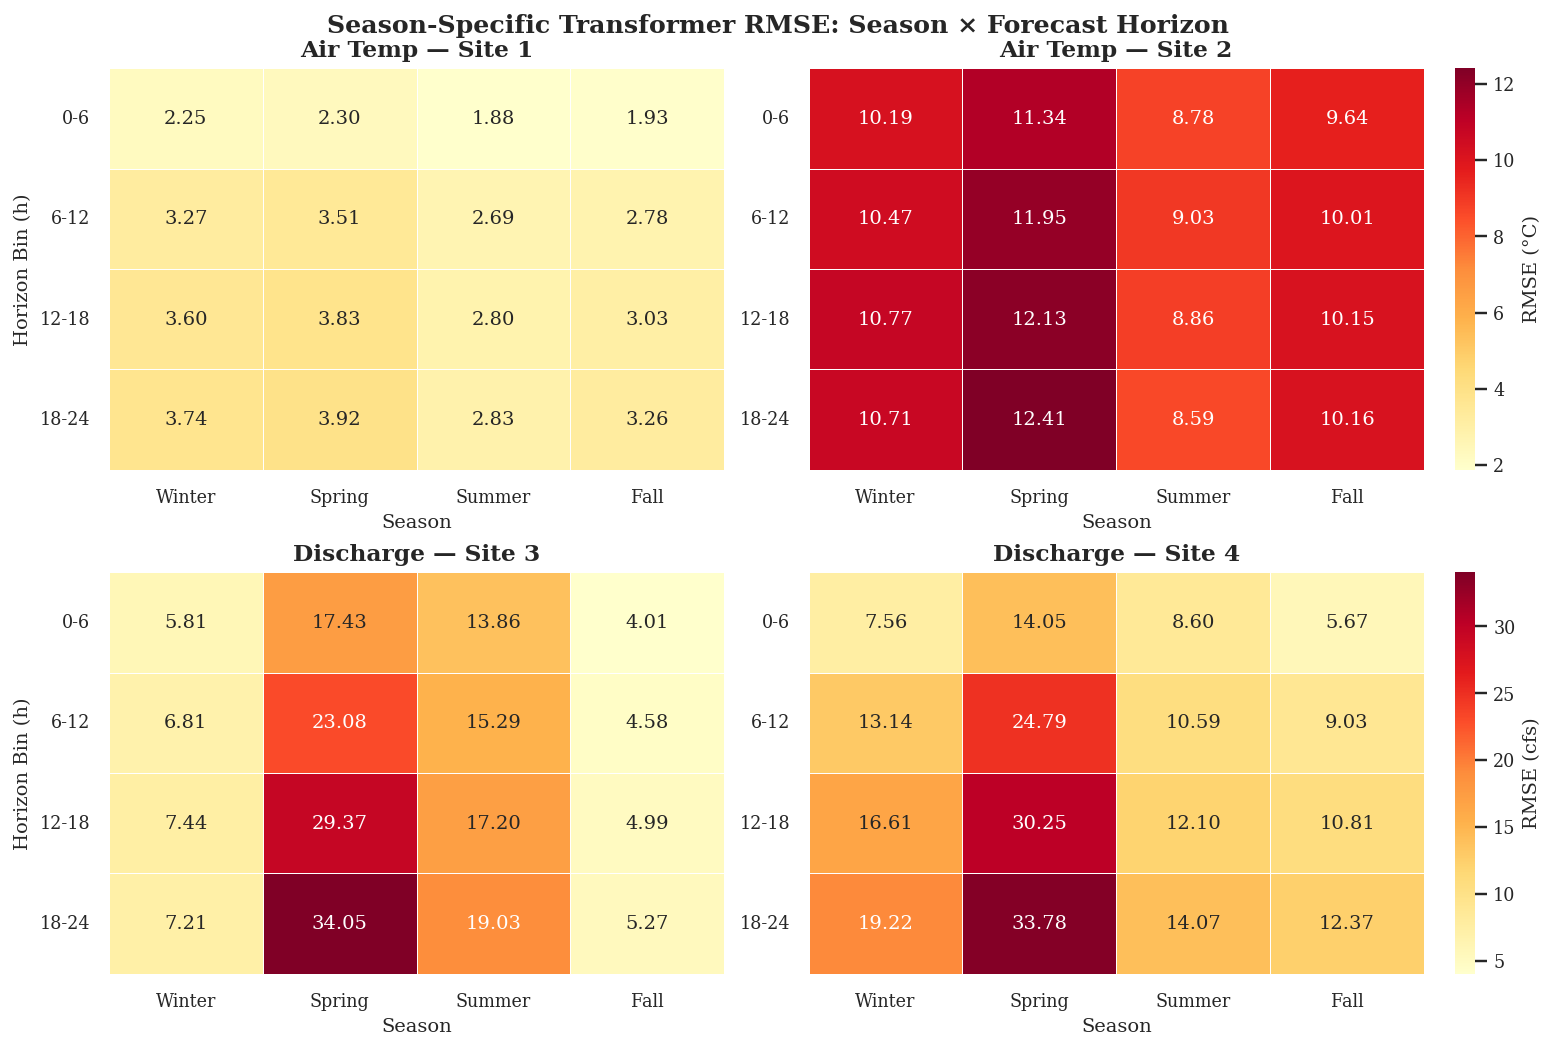

In [9]:
AIRTEMP_HORIZON_PATH = ROOT / 'season_specific_training' / 'metrics' / 'air_temperature_season_specific_metrics_by_season_horizon.csv'

airtemp_horizon = pd.read_csv(AIRTEMP_HORIZON_PATH)
airtemp_horizon['season'] = pd.Categorical(airtemp_horizon['season'], categories=SEASON_ORDER, ordered=True)
airtemp_horizon['horizon_bin'] = pd.Categorical(airtemp_horizon['horizon_bin'], categories=HORIZON_ORDER, ordered=True)

def make_pivot(df, site):
    return (
        df[df['site_id'] == site]
        .pivot(index='horizon_bin', columns='season', values='rmse')
        .reindex(index=HORIZON_ORDER, columns=SEASON_ORDER)
        .rename(columns=dict(zip(SEASON_ORDER, SEASON_LABELS)))
    )

at_pivots = {site: make_pivot(airtemp_horizon, site) for site in [1, 2]}
dq_pivots = {site: make_pivot(trans_horizon[trans_horizon['model'] == 'Season-Specific Transformer'], site) for site in [3, 4]}

# Shared colour bounds within each variable
at_vmin = min(p.min().min() for p in at_pivots.values())
at_vmax = max(p.max().max() for p in at_pivots.values())
dq_vmin = min(p.min().min() for p in dq_pivots.values())
dq_vmax = max(p.max().max() for p in dq_pivots.values())

fig, axes = plt.subplots(2, 2, figsize=(11, 7.2), constrained_layout=True)

hm_kwargs = dict(cmap='YlOrRd', annot=True, fmt='.2f', linewidths=0.5, linecolor='white')

for col, site in enumerate([1, 2]):
    ax = axes[0, col]
    show_cbar = col == 1
    sns.heatmap(at_pivots[site], ax=ax, vmin=at_vmin, vmax=at_vmax, cbar=show_cbar, **hm_kwargs)
    ax.set_title(f'Air Temp — Site {site}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Season')
    ax.set_ylabel('Horizon Bin (h)' if col == 0 else '')
    ax.set_yticklabels(HORIZON_ORDER, rotation=0)
    if show_cbar:
        ax.collections[-1].colorbar.set_label('RMSE (°C)')

for col, site in enumerate([3, 4]):
    ax = axes[1, col]
    show_cbar = col == 1
    sns.heatmap(dq_pivots[site], ax=ax, vmin=dq_vmin, vmax=dq_vmax, cbar=show_cbar, **hm_kwargs)
    ax.set_title(f'Discharge — Site {site}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Season')
    ax.set_ylabel('Horizon Bin (h)' if col == 0 else '')
    ax.set_yticklabels(HORIZON_ORDER, rotation=0)
    if show_cbar:
        ax.collections[-1].colorbar.set_label('RMSE (cfs)')

fig.suptitle('Season-Specific Transformer RMSE: Season × Forecast Horizon',
             fontsize=13, fontweight='bold', y=1.02)
plt.show()
